# E-commerce Product Analysis Project

The following analysis is performed on dataset from Kaggle.

##### Credits:

https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop

https://rees46.com/

**Project goal is to analyze user behavior in an e-commerce cosmetics shop and identify factors associated with successful purchases.**

## Business Context

The dataset contains user event history from an online cosmetics store.

Users interact with products through several types of events:

view — product viewed;
cart — product added to cart;
remove_from_cart — product removed from cart;
purchase — product purchased.

The business wants to understand:

*How do users move through the shopping funnel, where are potential customers lost, and what user/product characteristics are associated with a higher probability of purchase?*

The final goal is **to identify product opportunities that could potentially improve purchase conversion.**

## Import Required Python Libraries

In [3]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

## Dataset Installation

In [4]:
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

dataset_path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop",
    output_dir=str(data_dir.resolve()),
)

print(f"Dataset downloaded to: {dataset_path}")

Dataset downloaded to: /Users/likanikolaidi/ecommerce-product-analysis/data


## Dataset Properties Description

**event_time**	Time when event happened at (in UTC).

**event_type**	Four kinds of event: purchase, cart, view, remove_from_cart.

**product_id**	ID of a product

**category_id**	Product's category ID

**category_code**	Product's category taxonomy (code name) if it was possible to make it. Usually present for meaningful categories and skipped for different kinds of accessories.

**brand**	Downcased string of brand name. Can be missed.

**price**	Float price of a product. Present.

**user_id**	Permanent user ID.

**user_session**  Temporary user's session ID. Same for each user's session. Is changed every time user come back to online store from a long pause.

## Data Inspection

In [5]:
csv_files = sorted(data_dir.rglob("*.csv"))
for file in csv_files:
    print(file.name, f"{file.stat().st_size / 1e9:.2f} GB")

2019-Dec.csv 0.42 GB
2019-Nov.csv 0.55 GB
2019-Oct.csv 0.48 GB
2020-Feb.csv 0.49 GB
2020-Jan.csv 0.50 GB


In [6]:
sample = pd.read_csv(csv_files[0], nrows=100_000)
sample.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5


In [11]:
# inspecting the sample
print(sample.shape)
print(sample.columns)
print(sample.dtypes)
print(sample.isna().sum())

(100000, 9)
Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='str')
event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object
event_time           0
event_type           0
product_id           0
category_id          0
category_code    98309
brand            43558
price                0
user_id              0
user_session        43
dtype: int64


For the computational resource economy the whole exploratory pipline will be first set up for one month data only

In [ ]:
oct_df = pd.read_csv("data/2019-Oct.csv")
oct_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


## Data Quality Checks

Includes duplicates, date range, event types, and counts of unique users, sessions, products, categories, and brands.

In [18]:
df = oct_df

In [19]:
EXPECTED_COLUMNS = {
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session",
}

EXPECTED_EVENT_TYPES = {
    "view",
    "cart",
    "remove_from_cart",
    "purchase",
}


def run_data_quality_checks(df):
    missing_columns = EXPECTED_COLUMNS - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    event_time = pd.to_datetime(
        df["event_time"],
        errors="coerce",
        utc=True,
    )

    overview = pd.Series({
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "invalid_event_times": event_time.isna().sum(),
        "date_min": event_time.min(),
        "date_max": event_time.max(),
        "unique_users": df["user_id"].nunique(dropna=True),
        "unique_sessions": df["user_session"].nunique(dropna=True),
        "unique_products": df["product_id"].nunique(dropna=True),
        "unique_categories": df["category_id"].nunique(dropna=True),
        "unique_brands": df["brand"].nunique(dropna=True),
        "non_positive_prices": df["price"].le(0).sum(),
    }, name="value")

    missing_values = (
        pd.DataFrame({
            "missing_count": df.isna().sum(),
            "missing_percent": df.isna().mean().mul(100),
        })
        .sort_values("missing_percent", ascending=False)
    )

    data_types = df.dtypes.rename("data_type").to_frame()

    event_distribution = (
        df["event_type"]
        .value_counts(dropna=False)
        .rename_axis("event_type")
        .to_frame("event_count")
    )
    event_distribution["percent"] = (
        event_distribution["event_count"]
        .div(len(df))
        .mul(100)
    )

    unexpected_events = sorted(
        set(df["event_type"].dropna().unique())
        - EXPECTED_EVENT_TYPES
    )

    return {
        "overview": overview,
        "data_types": data_types,
        "missing_values": missing_values,
        "event_distribution": event_distribution,
        "unexpected_events": unexpected_events,
    }

In [20]:
quality_report = run_data_quality_checks(df)

display(quality_report["overview"])
display(quality_report["data_types"])
display(quality_report["missing_values"])
display(quality_report["event_distribution"])

print(
    "Unexpected event types:",
    quality_report["unexpected_events"],
)

rows                                     4102283
columns                                        9
duplicate_rows                            213155
invalid_event_times                            0
date_min               2019-10-01 00:00:00+00:00
date_max               2019-10-31 23:59:54+00:00
unique_users                              399664
unique_sessions                           873960
unique_products                            41899
unique_categories                            490
unique_brands                                240
non_positive_prices                         6086
Name: value, dtype: object

,data_type
event_time,str
event_type,str
product_id,int64
category_id,int64
category_code,str
brand,str
price,float64
user_id,int64
user_session,str


,missing_count,missing_percent
category_code,4034806,98.355135
brand,1659261,40.447258
user_session,637,0.015528
event_time,0,0.000000
event_type,0,0.000000
category_id,0,0.000000
product_id,0,0.000000
price,0,0.000000
user_id,0,0.000000


,event_count,percent
event_type,,
view,1862164,45.393358
cart,1232385,30.041443
remove_from_cart,762110,18.577704
purchase,245624,5.987495


Unexpected event types: []


### Investigating questionable records

These records' analysis include duplicate rows (which can legitimately occur) and invalid (negative) prices.

In [21]:
duplicate_mask = df.duplicated(keep=False)

display(
    df.loc[duplicate_mask, "event_type"]
    .value_counts()
    .to_frame("rows_in_duplicate_groups")
)

display(
    df.loc[duplicate_mask]
    .sort_values(
        ["user_id", "user_session", "product_id", "event_time"]
    )
    .head(30)
)

,rows_in_duplicate_groups
event_type,
remove_from_cart,363653
cart,53670
purchase,686
view,228


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
137746,2019-10-01 22:06:07 UTC,remove_from_cart,5739036,1487580008246412266,NaN,kapous,3.32,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137748,2019-10-01 22:06:07 UTC,remove_from_cart,5739036,1487580008246412266,NaN,kapous,3.32,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137684,2019-10-01 22:05:27 UTC,remove_from_cart,5812138,1487580013413793985,NaN,art-visage,4.68,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
137685,2019-10-01 22:05:27 UTC,remove_from_cart,5812138,1487580013413793985,NaN,art-visage,4.68,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb
266253,2019-10-02 14:43:55 UTC,remove_from_cart,5709126,1487580011752849537,NaN,elskin,4.21,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266256,2019-10-02 14:43:55 UTC,remove_from_cart,5709126,1487580011752849537,NaN,elskin,4.21,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266393,2019-10-02 14:44:45 UTC,remove_from_cart,5823668,1487580008246412266,NaN,kapous,7.60,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
266396,2019-10-02 14:44:45 UTC,remove_from_cart,5823668,1487580008246412266,NaN,kapous,7.60,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad
3535082,2019-10-27 16:00:04 UTC,remove_from_cart,5807805,1487580005713052531,NaN,ingarden,4.44,10280338,fbacb4a3-2141-4f43-b9e5-97c911c7e770
3535083,2019-10-27 16:00:04 UTC,remove_from_cart,5807805,1487580005713052531,NaN,ingarden,4.44,10280338,fbacb4a3-2141-4f43-b9e5-97c911c7e770


In [33]:
invalid_prices = df.loc[df["price"] <= 0]

display(invalid_prices["price"].describe())
display(invalid_prices["event_type"].value_counts())
display(invalid_prices.sample(5))
display(invalid_prices.loc[invalid_prices["price"] <= -20])

count    6086.000000
mean       -0.091285
std         1.906700
min       -79.370000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: price, dtype: float64

event_type
view                5372
cart                 540
remove_from_cart     154
purchase              20
Name: count, dtype: int64

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3954463,2019-10-30 18:52:46 UTC,view,5892679,1487580008263189483,NaN,NaN,0.0,504242074,42fb4e31-ec57-45fb-9c98-20c6b6b4d14e
3206374,2019-10-24 18:10:36 UTC,view,5896449,1487580007675986893,NaN,NaN,0.0,500771270,6c977b05-453a-494e-927d-348a556753a8
2848762,2019-10-22 05:19:27 UTC,view,5894508,1487580011702517887,NaN,NaN,0.0,562817002,ec305a0b-4133-49b5-9e67-6403691883ce
3803063,2019-10-29 15:17:37 UTC,view,5891052,1783999068909863670,NaN,NaN,0.0,551119191,698dbbfd-6611-4974-9ac4-46a78345551e
3182956,2019-10-24 14:35:21 UTC,view,5896719,1487580007675986893,NaN,NaN,0.0,558605370,0f88922b-e94f-4890-b4bc-bf4ef89335ef


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
112860,2019-10-01 19:10:56 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,552507528,dcdd60c6-1a70-442d-bfb2-0252879054ad
436918,2019-10-03 17:37:04 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,555414763,479149eb-1807-4178-8f6b-87c642350735
1519246,2019-10-11 10:27:19 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,543647038,85e11d74-6583-4eab-b50c-ff86dbb25d97
1783312,2019-10-13 16:46:01 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,559820267,f178c995-f004-4040-b26d-b1cca0f9657d
1924072,2019-10-14 17:33:24 UTC,purchase,5716861,1487580014042939619,NaN,NaN,-79.37,541122983,b60f777d-afca-4299-8548-273b810d6130
2143762,2019-10-16 11:41:06 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,461943726,beefa8fb-a3d1-48ca-97e9-9c95b05ee997
3135434,2019-10-24 08:10:06 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,545859098,95ed1875-cb64-443d-90bb-17d0dc596c10
3502423,2019-10-27 11:24:32 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,564627373,81d564e9-55b3-4929-9132-6353cab08a97
3608726,2019-10-28 07:41:54 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,385939606,2255291d-8060-4ce9-934c-458a3bd0b944
3798007,2019-10-29 14:34:24 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,554081558,4b84a8f9-97d7-4eb1-b120-7b34ddfe9a85


This analysis provides following conclusions:

- The concentration of duplicate rows in cart-removal events suggests these may represent quantity changes or repeated actions rather than random file duplication. Because timestamps only have one-second precision, two legitimate events can also appear identical.

- Zero-price rows often also lack brand/category information, suggesting incomplete product-catalog records. Negative purchase prices are more concerning, but the dataset does not provide enough evidence to classify them as returns, discounts, or errors and the amount of these rows is relatively small.

## Cleaning Pipeline

In [37]:
def clean_event_data(raw_df, drop_exact_duplicates=False):
    clean_df = raw_df.copy()

    # Parse timestamps consistently as UTC
    clean_df["event_time"] = pd.to_datetime(
        clean_df["event_time"],
        errors="coerce",
        utc=True,
    )

    # Standardize text values
    text_columns = ["event_type", "category_code", "brand", "user_session"]

    for column in text_columns:
        clean_df[column] = (
            clean_df[column]
            .astype("string")
            .str.strip()
        )
        clean_df[column] = clean_df[column].mask(
            clean_df[column].eq(""),
            pd.NA,
        )

    clean_df["event_type"] = clean_df["event_type"].str.lower()
    clean_df["brand"] = clean_df["brand"].str.lower()
    clean_df["category_code"] = clean_df["category_code"].str.lower()

    # Validate essential fields
    essential_columns = [
        "event_time",
        "event_type",
        "product_id",
        "category_id",
        "price",
        "user_id",
    ]

    clean_df = clean_df.dropna(subset=essential_columns)

    # Flag valid prices
    clean_df["is_valid_price"] = clean_df["price"] > 0

    # Useful time fields for later aggregation
    clean_df["event_date"] = clean_df["event_time"].dt.floor("D")
    clean_df["event_month"] = (
    clean_df["event_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

    # Duplicate removal remains optional
    if drop_exact_duplicates:
        clean_df = clean_df.drop_duplicates(ignore_index=True)

    return clean_df

In [38]:
clean_df = clean_event_data(
    df,
    drop_exact_duplicates=False,
)

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4102283 entries, 0 to 4102282
Data columns (total 12 columns):
 #   Column          Dtype              
---  ------          -----              
 0   event_time      datetime64[us, UTC]
 1   event_type      string             
 2   product_id      int64              
 3   category_id     int64              
 4   category_code   string             
 5   brand           string             
 6   price           float64            
 7   user_id         int64              
 8   user_session    string             
 9   is_valid_price  bool               
 10  event_date      datetime64[us, UTC]
 11  event_month     period[M]          
dtypes: bool(1), datetime64[us, UTC](2), float64(1), int64(3), period[M](1), string(4)
memory usage: 348.2 MB


## Event Overview

This section measures total recorded activity, number of recorded event rows by event type.

In [39]:
EVENT_ORDER = [
    "view",
    "cart",
    "remove_from_cart",
    "purchase",
]

event_overview = (
    df.groupby("event_type")
    .agg(
        event_count=("event_type", "size"),
        unique_users=("user_id", "nunique"),
        unique_sessions=("user_session", "nunique"),
    )
    .reindex(EVENT_ORDER)
    .reset_index()
)

event_overview["event_percent"] = (
    event_overview["event_count"]
    .div(event_overview["event_count"].sum())
    .mul(100)
)

event_overview

display(
    event_overview.style.format({
        "event_count": "{:,.0f}",
        "event_percent": "{:.2f}%",
        "unique_users": "{:,.0f}",
        "unique_sessions": "{:,.0f}",
    })
)

,event_type,event_count,unique_users,unique_sessions,event_percent
0,view,"1,862,164","388,331","826,147",45.39%
1,cart,"1,232,385","133,818","228,145",30.04%
2,remove_from_cart,"762,110","47,090","91,973",18.58%
3,purchase,"245,624","25,762","29,326",5.99%


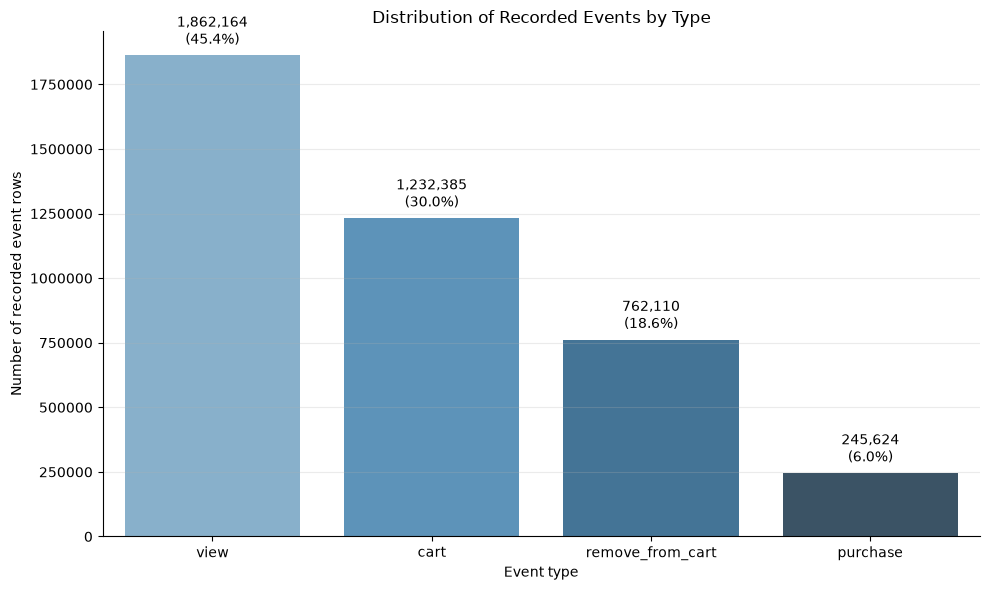

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=event_overview,
    x="event_type",
    y="event_count",
    hue="event_type",
    order=EVENT_ORDER,
    palette="Blues_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, event_overview.itertuples()):
    ax.annotate(
        f"{row.event_count:,.0f}\n({row.event_percent:.1f}%)",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Distribution of Recorded Events by Type")
ax.set_xlabel("Event type")
ax.set_ylabel("Number of recorded event rows")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

#### Duplicate Sensivity Check

The exact duplicates were not excluded from the counts above, so additional check is required.

In [41]:
deduplicated_counts = (
    df.drop_duplicates()
    ["event_type"]
    .value_counts()
    .reindex(EVENT_ORDER)
)

duplicate_sensitivity = (
    event_overview[
        ["event_type", "event_count"]
    ]
    .set_index("event_type")
    .rename(columns={"event_count": "raw_event_rows"})
)

duplicate_sensitivity["exact_deduplicated_rows"] = (
    deduplicated_counts
)

duplicate_sensitivity["excess_rows"] = (
    duplicate_sensitivity["raw_event_rows"]
    - duplicate_sensitivity["exact_deduplicated_rows"]
)

duplicate_sensitivity["excess_percent"] = (
    duplicate_sensitivity["excess_rows"]
    .div(duplicate_sensitivity["raw_event_rows"])
    .mul(100)
)

display(
    duplicate_sensitivity.style.format({
        "raw_event_rows": "{:,.0f}",
        "exact_deduplicated_rows": "{:,.0f}",
        "excess_rows": "{:,.0f}",
        "excess_percent": "{:.2f}%",
    })
)

,raw_event_rows,exact_deduplicated_rows,excess_rows,excess_percent
event_type,,,,
view,"1,862,164","1,862,050",114,0.01%
cart,"1,232,385","1,204,218","28,167",2.29%
remove_from_cart,"762,110","577,579","184,531",24.21%
purchase,"245,624","245,281",343,0.14%


Views are the most frequent recorded event, followed by cart and remove-from-cart events. Purchases represent the smallest share. These event percentages are not conversion rates because users and sessions can generate repeated events. Exact duplicates are especially concentrated in cart-removal activity, so raw counts are retained while the deduplicated results are reported as a sensitivity check.

## Product Funnel

This section uses a strict, ordered user-product funnel. Each (user_id, product_id) pair is counted once, regardless of repeated events.

The funnel unit is a user-product interaction during the observation period. A pair reaches cart only if a cart event occurs after its view, and reaches purchase only if a purchase occurs after that cart.

#### Prepare ordered funnel events

In [42]:
FUNNEL_EVENTS = ["view", "cart", "purchase"]
FUNNEL_KEYS = ["user_id", "product_id"]

funnel_events = (
    df.loc[
        df["event_type"].isin(FUNNEL_EVENTS),
        FUNNEL_KEYS + ["event_time", "event_type"],
    ]
    .copy()
)

funnel_events["event_time"] = pd.to_datetime(
    funnel_events["event_time"],
    errors="coerce",
    utc=True,
)

funnel_events = (
    funnel_events
    .dropna(subset=FUNNEL_KEYS + ["event_time", "event_type"])
    .sort_values("event_time", kind="stable")
    .reset_index(drop=True)
)

# Provides an unambiguous order when events share a timestamp.
funnel_events["event_order"] = np.arange(len(funnel_events))

#### Finding the first view for each pair

In [43]:
first_views = (
    funnel_events.loc[
        funnel_events["event_type"].eq("view")
    ]
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_view_time",
        "event_order": "first_view_order",
    })
)
first_views.head()

,user_id,product_id,first_view_time,first_view_order
9,474232307,5875317,2019-10-01 00:00:26+00:00,9
10,555446068,5692917,2019-10-01 00:00:28+00:00,10
14,546705258,5819638,2019-10-01 00:00:48+00:00,14
16,507355498,5856191,2019-10-01 00:00:53+00:00,16
22,543446752,5733176,2019-10-01 00:01:11+00:00,22


Every row in first_views represents one funnel unit.

#### Finding the first cart after the view

In [44]:
cart_candidates = (
    funnel_events.loc[
        funnel_events["event_type"].eq("cart")
    ]
    .merge(
        first_views[
            FUNNEL_KEYS + ["first_view_order"]
        ],
        on=FUNNEL_KEYS,
        how="inner",
    )
)

cart_candidates = cart_candidates.loc[
    cart_candidates["event_order"]
    > cart_candidates["first_view_order"]
]

first_carts = (
    cart_candidates
    .sort_values("event_order")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_cart_time",
        "event_order": "first_cart_order",
    })
)

first_carts.head()

,user_id,product_id,first_cart_time,first_cart_order
9,474232307,5875317,2019-10-01 00:01:13+00:00,24
13,520558067,5597836,2019-10-01 00:02:08+00:00,41
14,546705258,5775980,2019-10-01 00:02:57+00:00,59
16,401329661,5852507,2019-10-01 00:03:26+00:00,69
17,429681830,5881589,2019-10-01 00:03:31+00:00,70


An earlier cart without a preceding view does not qualify, but a later cart after a view does.

#### Finding the first purchase after cart

In [45]:
purchase_candidates = (
    funnel_events.loc[
        funnel_events["event_type"].eq("purchase")
    ]
    .merge(
        first_carts[
            FUNNEL_KEYS + ["first_cart_order"]
        ],
        on=FUNNEL_KEYS,
        how="inner",
    )
)

purchase_candidates = purchase_candidates.loc[
    purchase_candidates["event_order"]
    > purchase_candidates["first_cart_order"]
]

first_purchases = (
    purchase_candidates
    .sort_values("event_order")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    [FUNNEL_KEYS + ["event_time", "event_order"]]
    .rename(columns={
        "event_time": "first_purchase_time",
        "event_order": "first_purchase_order",
    })
)

first_purchases.head()

,user_id,product_id,first_purchase_time,first_purchase_order
0,474232307,5875317,2019-10-01 00:06:35+00:00,146
7,385985999,5587756,2019-10-01 00:21:42+00:00,539
8,385985999,5692866,2019-10-01 00:21:42+00:00,540
9,509896854,5884577,2019-10-01 00:40:00+00:00,796
10,446404021,5849033,2019-10-01 00:55:17+00:00,1017


#### Assembling the funnel table

Repeated views, carts, or purchases do not inflate the funnel because each pair has only one row.

In [46]:
user_product_funnel = (
    first_views
    .merge(
        first_carts,
        on=FUNNEL_KEYS,
        how="left",
    )
    .merge(
        first_purchases,
        on=FUNNEL_KEYS,
        how="left",
    )
)

user_product_funnel["reached_view"] = True
user_product_funnel["reached_cart"] = (
    user_product_funnel["first_cart_time"].notna()
)
user_product_funnel["reached_purchase"] = (
    user_product_funnel["first_purchase_time"].notna()
)

user_product_funnel.head()

,user_id,product_id,first_view_time,first_view_order,first_cart_time,first_cart_order,first_purchase_time,first_purchase_order,reached_view,reached_cart,reached_purchase
0,474232307,5875317,2019-10-01 00:00:26+00:00,9,2019-10-01 00:01:13+00:00,24.0,2019-10-01 00:06:35+00:00,146.0,True,True,True
1,555446068,5692917,2019-10-01 00:00:28+00:00,10,NaT,NaN,NaT,NaN,True,False,False
2,546705258,5819638,2019-10-01 00:00:48+00:00,14,NaT,NaN,NaT,NaN,True,False,False
3,507355498,5856191,2019-10-01 00:00:53+00:00,16,NaT,NaN,NaT,NaN,True,False,False
4,543446752,5733176,2019-10-01 00:01:11+00:00,22,NaT,NaN,NaT,NaN,True,False,False


#### Calculating stage counts and conversion

In [47]:
view_count = len(user_product_funnel)

cart_count = (
    user_product_funnel["reached_cart"].sum()
)

purchase_count = (
    user_product_funnel["reached_purchase"].sum()
)

view_to_cart = (
    cart_count / view_count
    if view_count
    else np.nan
)

cart_to_purchase = (
    purchase_count / cart_count
    if cart_count
    else np.nan
)

view_to_purchase = (
    purchase_count / view_count
    if view_count
    else np.nan
)

conversion_metrics = pd.DataFrame({
    "metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase",
    ],
    "numerator": [
        cart_count,
        purchase_count,
        purchase_count,
    ],
    "denominator": [
        view_count,
        cart_count,
        view_count,
    ],
    "conversion_rate": [
        view_to_cart,
        cart_to_purchase,
        view_to_purchase,
    ],
})

display(
    conversion_metrics.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
    })
)

,metric,numerator,denominator,conversion_rate
0,View → Cart,"226,240","1,402,922",16.13%
1,Cart → Purchase,"55,353","226,240",24.47%
2,View → Purchase,"55,353","1,402,922",3.95%


#### Visualizing the funnel

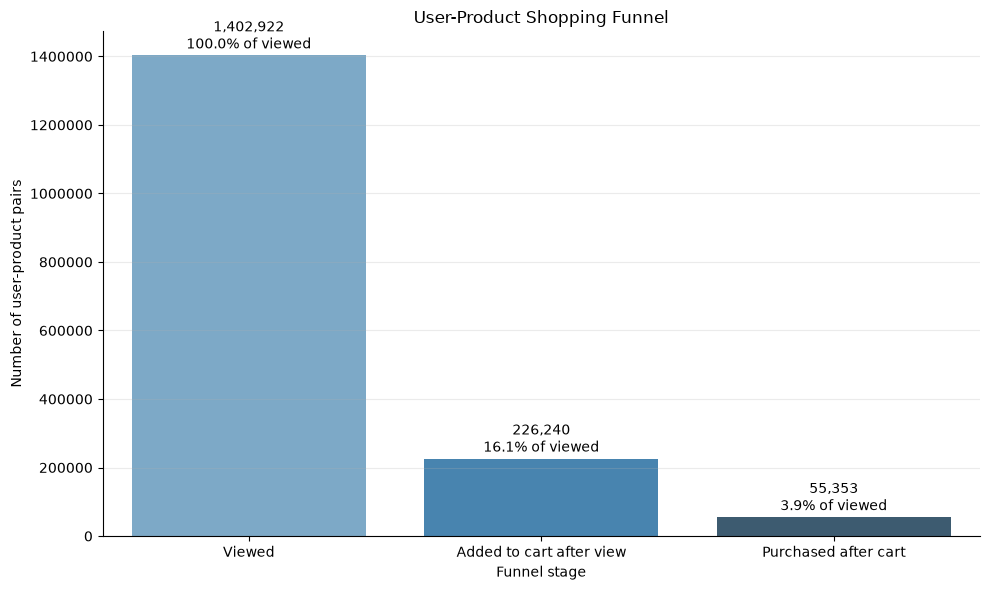

In [49]:
funnel_stages = pd.DataFrame({
    "stage": [
        "Viewed",
        "Added to cart after view",
        "Purchased after cart",
    ],
    "user_product_pairs": [
        view_count,
        cart_count,
        purchase_count,
    ],
})

funnel_stages["percent_of_viewed"] = (
    funnel_stages["user_product_pairs"]
    .div(view_count)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=funnel_stages,
    x="stage",
    y="user_product_pairs",
    hue="stage",
    palette="Blues_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, funnel_stages.itertuples()):
    ax.annotate(
        (
            f"{row.user_product_pairs:,.0f}\n"
            f"{row.percent_of_viewed:.1f}% of viewed"
        ),
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("User-Product Shopping Funnel")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Number of user-product pairs")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

#### Metric interpretation
- View → Cart: among viewed user-product pairs, how many later reached cart. This measures whether product interest progresses to purchase intent.
- Cart → Purchase: among pairs that reached cart after viewing, how many were later purchased. This measures completion after purchase intent.
- View → Purchase: among viewed pairs, how many completed the entire ordered funnel. This is the end-to-end conversion rate.


The user-product funnel answers the question:

**How effectively does interest in a particular product lead to its purchase?**

So according to the key end-to-end metric the conversion rate is 3.95%.

## Session-Level Funnel

Defining the unit as one (user_id, user_session) pair. Repeated events are reduced to Boolean stage indicators.

#### Building session-level flags

In [50]:
SESSION_KEYS = ["user_id", "user_session"]

missing_session_rows = df["user_session"].isna().sum()

print(f"Rows excluded because session is missing: {missing_session_rows:,}")

Rows excluded because session is missing: 637


In [51]:
session_events = (
    df.loc[
        df["user_session"].notna(),
        SESSION_KEYS + ["event_type"],
    ]
    .copy()
)

session_events["has_view"] = (
    session_events["event_type"].eq("view")
)

session_events["has_cart"] = (
    session_events["event_type"].eq("cart")
)

session_events["has_purchase"] = (
    session_events["event_type"].eq("purchase")
)

session_funnel = (
    session_events
    .groupby(SESSION_KEYS, as_index=False)
    .agg(
        has_view=("has_view", "max"),
        has_cart=("has_cart", "max"),
        has_purchase=("has_purchase", "max"),
    )
)

session_funnel.head()

,user_id,user_session,has_view,has_cart,has_purchase
0,4103071,8930ec72-36b0-4be9-80c7-af93b9f477c6,True,True,False
1,8846226,ddd23270-792c-49f3-9ae2-d86f5080a5eb,True,True,False
2,8846226,f835c9a8-cb8a-4201-85d4-00565bcc84ad,True,True,False
3,9794320,1be8fa80-8036-4d95-93da-494a08d82cb5,True,True,False
4,9794320,9f8afcc5-abe6-47a6-93d5-290d350cea5e,True,False,False


#### Creating nested funnel stages

This is a presence-based funnel: the events must occur in the same session, but their exact order is not enforced.

In [52]:
session_funnel["reached_view"] = (
    session_funnel["has_view"]
)

session_funnel["reached_cart"] = (
    session_funnel["has_view"]
    & session_funnel["has_cart"]
)

session_funnel["reached_purchase"] = (
    session_funnel["has_view"]
    & session_funnel["has_cart"]
    & session_funnel["has_purchase"]
)

#### Calculating session conversion

In [53]:
session_view_count = (
    session_funnel["reached_view"].sum()
)

session_cart_count = (
    session_funnel["reached_cart"].sum()
)

session_purchase_count = (
    session_funnel["reached_purchase"].sum()
)

session_view_to_cart = (
    session_cart_count / session_view_count
    if session_view_count
    else np.nan
)

session_cart_to_purchase = (
    session_purchase_count / session_cart_count
    if session_cart_count
    else np.nan
)

session_view_to_purchase = (
    session_purchase_count / session_view_count
    if session_view_count
    else np.nan
)

session_conversion_metrics = pd.DataFrame({
    "metric": [
        "View → Cart",
        "Cart → Purchase",
        "View → Purchase",
    ],
    "numerator": [
        session_cart_count,
        session_purchase_count,
        session_purchase_count,
    ],
    "denominator": [
        session_view_count,
        session_cart_count,
        session_view_count,
    ],
    "conversion_rate": [
        session_view_to_cart,
        session_cart_to_purchase,
        session_view_to_purchase,
    ],
})

display(
    session_conversion_metrics.style.format({
        "numerator": "{:,.0f}",
        "denominator": "{:,.0f}",
        "conversion_rate": "{:.2%}",
    })
)

,metric,numerator,denominator,conversion_rate
0,View → Cart,"190,750","826,170",23.09%
1,Cart → Purchase,"20,487","190,750",10.74%
2,View → Purchase,"20,487","826,170",2.48%


#### Investigating sessions entering mid-funnel

Some sessions may contain cart or purchase events without a view.

In [55]:
session_entry_diagnostics = pd.Series({
    "all_sessions": len(session_funnel),
    "sessions_without_view": (
        ~session_funnel["has_view"]
    ).sum(),
    "cart_without_view": (
        session_funnel["has_cart"]
        & ~session_funnel["has_view"]
    ).sum(),
    "purchase_without_view": (
        session_funnel["has_purchase"]
        & ~session_funnel["has_view"]
    ).sum(),
    "purchase_without_cart": (
        session_funnel["has_purchase"]
        & ~session_funnel["has_cart"]
    ).sum(),
})

display(session_entry_diagnostics)

all_sessions             873984
sessions_without_view     47814
cart_without_view         37397
purchase_without_view      7127
purchase_without_cart      5135
dtype: int64

#### Visualizing the session funnels

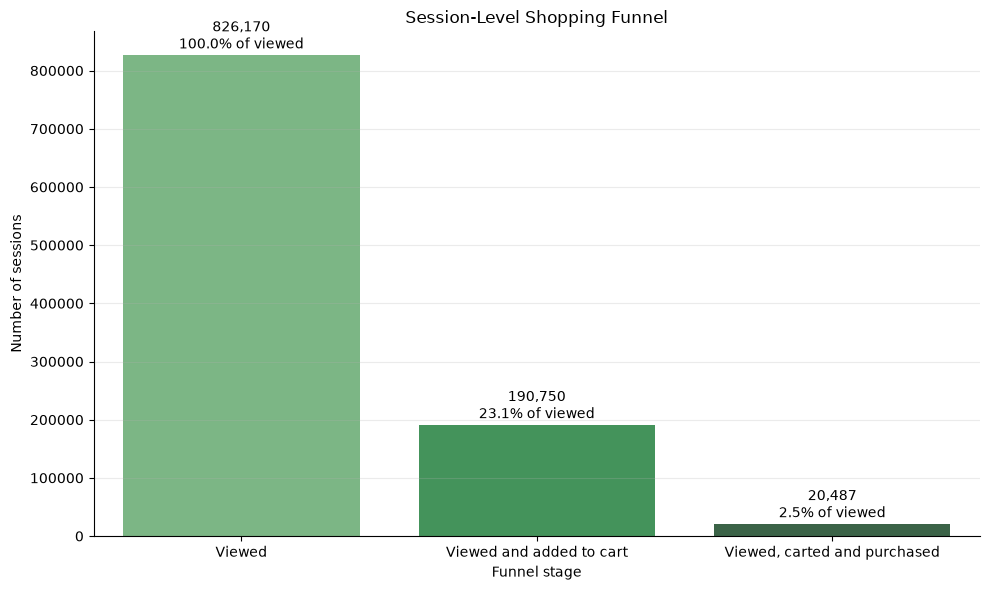

In [56]:
session_stages = pd.DataFrame({
    "stage": [
        "Viewed",
        "Viewed and added to cart",
        "Viewed, carted and purchased",
    ],
    "sessions": [
        session_view_count,
        session_cart_count,
        session_purchase_count,
    ],
})

session_stages["percent_of_viewed"] = (
    session_stages["sessions"]
    .div(session_view_count)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=session_stages,
    x="stage",
    y="sessions",
    hue="stage",
    palette="Greens_d",
    legend=False,
    ax=ax,
)

for bar, row in zip(ax.patches, session_stages.itertuples()):
    ax.annotate(
        f"{row.sessions:,.0f}\n"
        f"{row.percent_of_viewed:.1f}% of viewed",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )

ax.set_title("Session-Level Shopping Funnel")
ax.set_xlabel("Funnel stage")
ax.set_ylabel("Number of sessions")
ax.ticklabel_format(style="plain", axis="y")
ax.grid(axis="y", alpha=0.25)

sns.despine()
plt.tight_layout()
plt.show()

## Comparing both funnels

In [57]:
funnel_comparison = (
    conversion_metrics[
        ["metric", "conversion_rate"]
    ]
    .rename(columns={
        "conversion_rate": "user_product_rate"
    })
    .merge(
        session_conversion_metrics[
            ["metric", "conversion_rate"]
        ].rename(columns={
            "conversion_rate": "session_rate"
        }),
        on="metric",
        how="inner",
    )
)

funnel_comparison["difference_pp"] = (
    funnel_comparison["session_rate"]
    - funnel_comparison["user_product_rate"]
).mul(100)

display(
    funnel_comparison.style.format({
        "user_product_rate": "{:.2%}",
        "session_rate": "{:.2%}",
        "difference_pp": "{:+.2f} pp",
    })
)

,metric,user_product_rate,session_rate,difference_pp
0,View → Cart,16.13%,23.09%,+6.96 pp
1,Cart → Purchase,24.47%,10.74%,-13.73 pp
2,View → Purchase,3.95%,2.48%,-1.47 pp


Neither rate is inherently more correct as they measure different product questions.

The perspectives differ because:
- The user-product funnel requires progression for the same product, but events may span multiple sessions.
- The session funnel requires events within one visit, but the viewed, carted and purchased products can differ.
- A session can include many products and many repeated events.
- Some sessions begin at cart or purchase because earlier product activity occurred in another session.
- The session funnel has a shorter conversion window; the user-product funnel uses the entire observation period.

Important notice: in the future analysis user-product funnel is mostly going to be used as session funnel short conversion window in our case does not provide needed level of accuracy due to the limited amount of time included in the taken dataset.

## Conversion by Product Characteristics

This section is using the existing strict user_product_funnel. Product characteristics are coming from the pair’s first view so that they are measured at funnel entry.

In [58]:
from matplotlib.ticker import PercentFormatter

CHARACTERISTIC_COLUMNS = [
    "price",
    "category_id",
    "category_code",
    "brand",
]

first_view_characteristics = (
    df.loc[
        df["event_type"].eq("view"),
        FUNNEL_KEYS + ["event_time"] + CHARACTERISTIC_COLUMNS,
    ]
    .assign(
        event_time=lambda data: pd.to_datetime(
            data["event_time"],
            errors="coerce",
            utc=True,
        )
    )
    .dropna(subset=["event_time"])
    .sort_values("event_time", kind="stable")
    .drop_duplicates(FUNNEL_KEYS, keep="first")
    .rename(columns={
        "price": "view_price",
        "category_id": "view_category_id",
        "category_code": "view_category_code",
        "brand": "view_brand",
    })
)

characteristic_funnel = (
    user_product_funnel
    .merge(
        first_view_characteristics.drop(
            columns="event_time"
        ),
        on=FUNNEL_KEYS,
        how="left",
        validate="one_to_one",
    )
)

assert len(characteristic_funnel) == len(user_product_funnel)

In [59]:
def calculate_segment_conversion(data, segment):
    summary = (
        data.groupby(
            segment,
            observed=True,
            dropna=False,
        )
        .agg(
            viewed_pairs=("reached_view", "sum"),
            carted_pairs=("reached_cart", "sum"),
            purchased_pairs=("reached_purchase", "sum"),
        )
        .reset_index()
    )

    summary["view_to_cart"] = (
        summary["carted_pairs"]
        .div(summary["viewed_pairs"])
    )

    summary["cart_to_purchase"] = (
        summary["purchased_pairs"]
        .div(summary["carted_pairs"].replace(0, np.nan))
    )

    summary["view_to_purchase"] = (
        summary["purchased_pairs"]
        .div(summary["viewed_pairs"])
    )

    return summary

### Price analysis

#### Inspecting the price distribution

Inspecting prices at the user-product level, not across repeated event rows.

In [60]:
price_funnel = characteristic_funnel.loc[
    characteristic_funnel["view_price"] > 0
].copy()

invalid_price_pairs = (
    characteristic_funnel["view_price"] <= 0
).sum()

print(f"Valid-price pairs: {len(price_funnel):,}")
print(f"Non-positive-price pairs excluded: {invalid_price_pairs:,}")

display(
    price_funnel["view_price"].describe(
        percentiles=[
            0.01,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

Valid-price pairs: 1,398,705
Non-positive-price pairs excluded: 4,217


count    1.398705e+06
mean     1.215032e+01
std      2.504162e+01
min      5.000000e-02
1%       4.000000e-01
10%      1.430000e+00
25%      2.780000e+00
50%      5.060000e+00
75%      1.000000e+01
90%      2.357000e+01
95%      5.000000e+01
99%      1.377800e+02
max      3.076000e+02
Name: view_price, dtype: float64

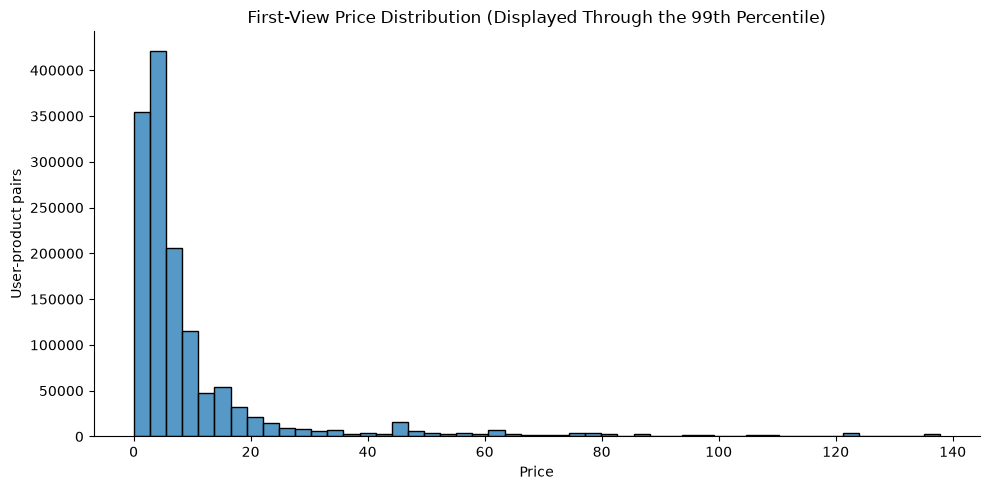

In [61]:
price_99th_percentile = (
    price_funnel["view_price"].quantile(0.99)
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=price_funnel.loc[
        price_funnel["view_price"] <= price_99th_percentile
    ],
    x="view_price",
    bins=50,
    ax=ax,
)

ax.set_title(
    "First-View Price Distribution "
    "(Displayed Through the 99th Percentile)"
)
ax.set_xlabel("Price")
ax.set_ylabel("User-product pairs")

sns.despine()
plt.tight_layout()
plt.show()

#### Creating data-driven price buckets

In [62]:
_, price_edges = pd.qcut(
    price_funnel["view_price"],
    q=5,
    retbins=True,
    duplicates="drop",
)

number_of_buckets = len(price_edges) - 1

PRICE_LABELS = {
    5: [
        "Low",
        "Medium-low",
        "Medium",
        "Medium-high",
        "High",
    ],
    4: [
        "Low",
        "Medium-low",
        "Medium-high",
        "High",
    ],
    3: ["Low", "Medium", "High"],
    2: ["Low", "High"],
}

if number_of_buckets not in PRICE_LABELS:
    raise ValueError(
        "Price distribution does not contain enough "
        "distinct values for meaningful buckets."
    )

price_labels = PRICE_LABELS[number_of_buckets]

price_funnel["price_bucket"] = pd.cut(
    price_funnel["view_price"],
    bins=price_edges,
    labels=price_labels,
    include_lowest=True,
)

price_bucket_boundaries = pd.DataFrame({
    "price_bucket": price_labels,
    "lower_boundary": price_edges[:-1],
    "upper_boundary": price_edges[1:],
})

display(price_bucket_boundaries)

,price_bucket,lower_boundary,upper_boundary
0,Low,0.05,2.38
1,Medium-low,2.38,4.11
2,Medium,4.11,6.19
3,Medium-high,6.19,12.38
4,High,12.38,307.60


#### Calculating price conversion

In [63]:
price_conversion = calculate_segment_conversion(
    price_funnel,
    "price_bucket",
)

display(
    price_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,price_bucket,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase
0,Low,"290,252","56,587","15,971",19.50%,28.22%,5.50%
1,Medium-low,"275,224","48,933","11,439",17.78%,23.38%,4.16%
2,Medium,"281,270","49,324","11,256",17.54%,22.82%,4.00%
3,Medium-high,"272,895","42,728","10,053",15.66%,23.53%,3.68%
4,High,"279,064","28,523","6,595",10.22%,23.12%,2.36%


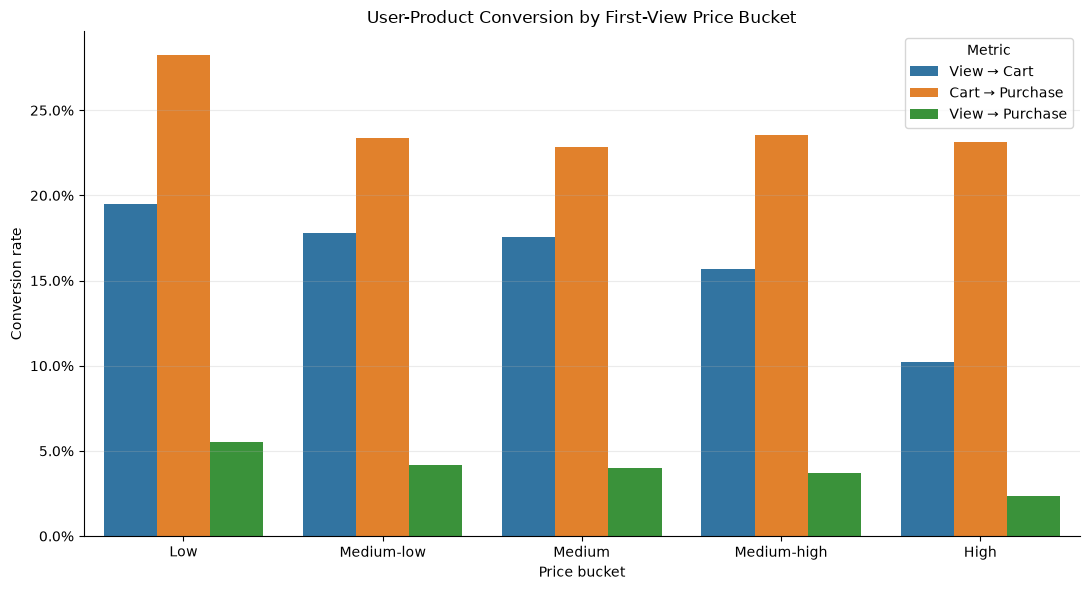

In [64]:
price_conversion_long = price_conversion.melt(
    id_vars=["price_bucket"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

PRICE_METRIC_LABELS = {
    "view_to_cart": "View → Cart",
    "cart_to_purchase": "Cart → Purchase",
    "view_to_purchase": "View → Purchase",
}

price_conversion_long["metric"] = (
    price_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=price_conversion_long,
    x="price_bucket",
    y="conversion_rate",
    hue="metric",
    order=price_labels,
    ax=ax,
)

ax.set_title("User-Product Conversion by First-View Price Bucket")
ax.set_xlabel("Price bucket")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

#### Intermediate Conclusions

Price is negatively associated with product conversion. The strongest difference occurs at the view-to-cart stage: high-price products have a 9.28 p.p. lower view-to-cart conversion than low-price products (10.22% vs. 19.50%). In contrast, cart-to-purchase conversion differs much less between the two groups (23.12% vs. 28.22%).

Important notice is that price buckets are quantile-based, so it may affect accuracy.

### Category analysis

Category IDs are available for most events, but human-readable category codes are missing for approximately 98% of records. Therefore, category analysis uses category IDs and focuses on relative differences between categories rather than semantic interpretation of individual categories.

#### Calculating category conversion and inspecting volume

In [65]:
category_conversion_all = calculate_segment_conversion(
    characteristic_funnel,
    "view_category_id",
)

display(
    category_conversion_all[
        ["viewed_pairs", "carted_pairs"]
    ].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
)

,viewed_pairs,carted_pairs
count,489.000000,489.000000
mean,2868.961145,462.658487
std,6534.177248,1012.308828
min,1.000000,0.000000
50%,784.000000,147.000000
75%,2350.000000,420.000000
90%,6738.400000,1192.000000
95%,10944.800000,1832.000000
max,59769.000000,10053.000000


In [66]:
MIN_CATEGORY_VIEWS = 1_000
MIN_CATEGORY_CARTS = 200
TOP_CATEGORY_COUNT = 15

category_conversion = (
    category_conversion_all.loc[
        (
            category_conversion_all["viewed_pairs"]
            >= MIN_CATEGORY_VIEWS
        )
        & (
            category_conversion_all["carted_pairs"]
            >= MIN_CATEGORY_CARTS
        )
    ]
    .nlargest(
        TOP_CATEGORY_COUNT,
        "viewed_pairs",
    )
    .copy()
)

category_conversion["category_label"] = (
    category_conversion["view_category_id"]
    .astype("string")
)

display(
    category_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,view_category_id,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase,category_label
97,1487580007675986893,"59,769","10,053","2,303",16.82%,22.91%,3.85%,1487580007675986893
10,1487580005092295511,"56,525","8,716","2,193",15.42%,25.16%,3.88%,1487580005092295511
30,1487580005671109489,"38,563","6,757","1,703",17.52%,25.20%,4.42%,1487580005671109489
122,1487580008246412266,"37,319","5,203","1,203",13.94%,23.12%,3.22%,1487580008246412266
50,1487580006300255120,"35,824","1,954",513,5.45%,26.25%,1.43%,1487580006300255120
51,1487580006317032337,"34,469","6,148","1,851",17.84%,30.11%,5.37%,1487580006317032337
307,1487580013841613016,"33,898","5,329",904,15.72%,16.96%,2.67%,1487580013841613016
13,1487580005268456287,"33,805","4,755","1,407",14.07%,29.59%,4.16%,1487580005268456287
312,1487580013950664926,"33,463","2,236",599,6.68%,26.79%,1.79%,1487580013950664926
336,1602943681873052386,"33,106","4,535","1,055",13.70%,23.26%,3.19%,1602943681873052386


#### Visualizing category conversion

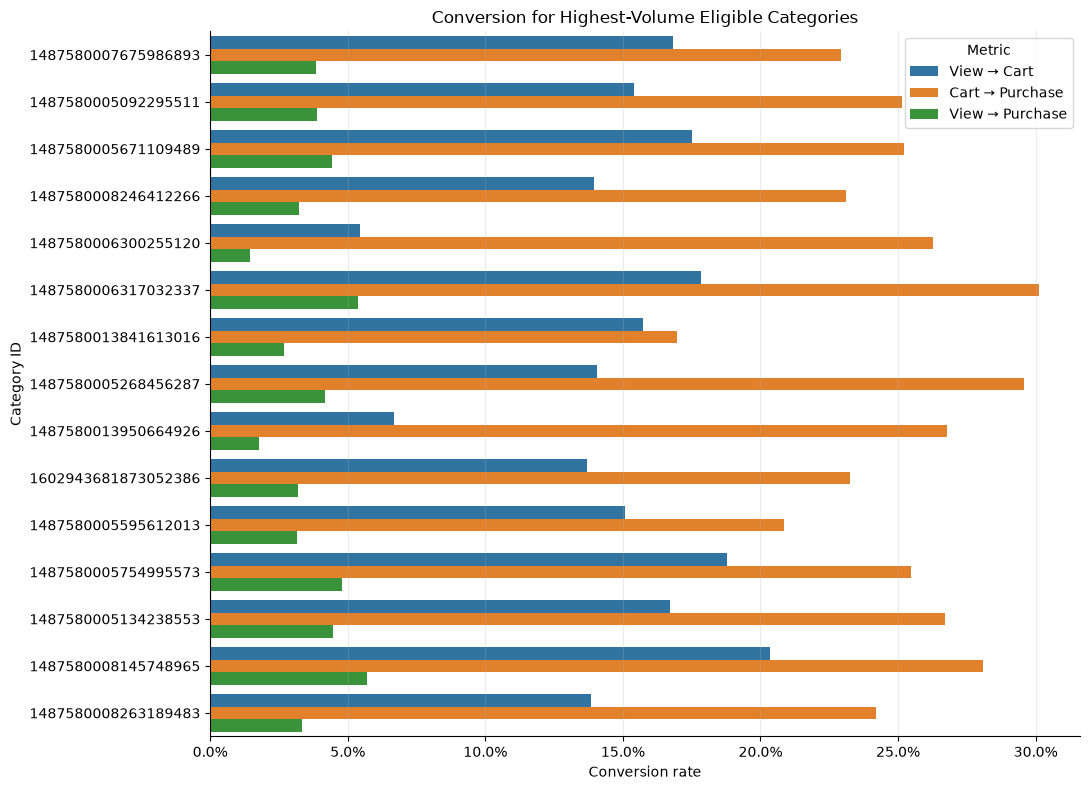

In [67]:
category_conversion_long = category_conversion.melt(
    id_vars=["category_label", "viewed_pairs"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

category_conversion_long["metric"] = (
    category_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

category_order = (
    category_conversion
    .sort_values("viewed_pairs", ascending=False)
    ["category_label"]
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=category_conversion_long,
    y="category_label",
    x="conversion_rate",
    hue="metric",
    order=category_order,
    ax=ax,
)

ax.set_title(
    "Conversion for Highest-Volume Eligible Categories"
)
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Category ID")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

The difference between conversion among different categories is drastical so future analysis combining categories with other factors is needed.

Observation to investigate:

Some categories demonstrate high cart-to-purchase conversion and relatively low view-to-cart conversion. It may be caused not by checkout problems, but rather be an issue with persuading the user to add the item to the cart

### Brand analysis

#### Preparing known brands

The data contains missing brands so it needs additional cleaning in order to avoid them.

In [71]:
brand_funnel = characteristic_funnel.copy()

brand_funnel["view_brand"] = (
    brand_funnel["view_brand"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace("", pd.NA)
)

missing_brand_percent = (
    brand_funnel["view_brand"]
    .isna()
    .mean()
    * 100
)

print(
    f"Pairs with missing first-view brand: "
    f"{missing_brand_percent:.2f}%"
)

Pairs with missing first-view brand: 40.13%


#### Selecting high-volume brands

In [72]:
brand_conversion_all = calculate_segment_conversion(
    brand_funnel.dropna(subset=["view_brand"]),
    "view_brand",
)

display(
    brand_conversion_all[
        ["viewed_pairs", "carted_pairs"]
    ].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95]
    )
)

,viewed_pairs,carted_pairs
count,239.000000,239.000000
mean,3514.635983,565.481172
std,9644.871556,1556.853789
min,1.000000,0.000000
50%,482.000000,84.000000
75%,2202.000000,345.500000
90%,8194.200000,1443.800000
95%,17241.800000,2410.400000
max,88745.000000,14643.000000


In [77]:
MIN_BRAND_VIEWS = 1_000
MIN_BRAND_CARTS = 200
TOP_BRAND_COUNT = 10

brand_conversion = (
    brand_conversion_all.loc[
        (
            brand_conversion_all["viewed_pairs"]
            >= MIN_BRAND_VIEWS
        )
        & (
            brand_conversion_all["carted_pairs"]
            >= MIN_BRAND_CARTS
        )
    ]
    .nlargest(
        TOP_BRAND_COUNT,
        "viewed_pairs",
    )
    .copy()
)

display(
    brand_conversion.style.format({
        "viewed_pairs": "{:,.0f}",
        "carted_pairs": "{:,.0f}",
        "purchased_pairs": "{:,.0f}",
        "view_to_cart": "{:.2%}",
        "cart_to_purchase": "{:.2%}",
        "view_to_purchase": "{:.2%}",
    })
)

,view_brand,viewed_pairs,carted_pairs,purchased_pairs,view_to_cart,cart_to_purchase,view_to_purchase
196,runail,"88,745","14,643","4,445",16.50%,30.36%,5.01%
105,irisk,"65,279","10,741","2,843",16.45%,26.47%,4.36%
153,masura,"58,240","9,458","2,119",16.24%,22.40%,3.64%
92,grattol,"46,483","6,720","1,648",14.46%,24.52%,3.55%
28,bpw.style,"33,436","5,781","1,546",17.29%,26.74%,4.62%
71,estel,"28,588","4,305","1,212",15.06%,28.15%,4.24%
100,ingarden,"26,379","4,691","1,123",17.78%,23.94%,4.26%
114,kapous,"24,634","3,149",906,12.78%,28.77%,3.68%
109,jessnail,"20,309","1,965",471,9.68%,23.97%,2.32%
36,concept,"19,536","2,507",688,12.83%,27.44%,3.52%


#### Visualizing brand conversion

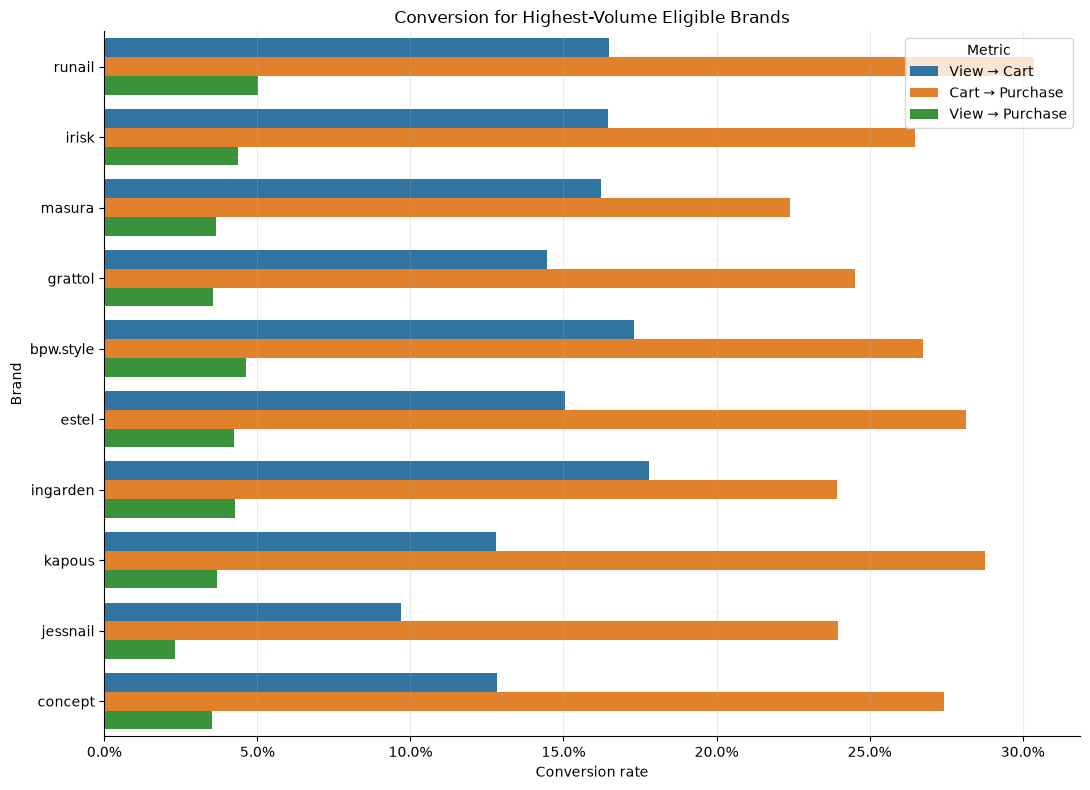

In [78]:
brand_conversion_long = brand_conversion.melt(
    id_vars=["view_brand", "viewed_pairs"],
    value_vars=[
        "view_to_cart",
        "cart_to_purchase",
        "view_to_purchase",
    ],
    var_name="metric",
    value_name="conversion_rate",
)

brand_conversion_long["metric"] = (
    brand_conversion_long["metric"]
    .map(PRICE_METRIC_LABELS)
)

brand_order = (
    brand_conversion
    .sort_values("viewed_pairs", ascending=False)
    ["view_brand"]
)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=brand_conversion_long,
    y="view_brand",
    x="conversion_rate",
    hue="metric",
    order=brand_order,
    ax=ax,
)

ax.set_title(
    "Conversion for Highest-Volume Eligible Brands"
)
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Brand")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=0.25)
ax.legend(title="Metric")

sns.despine()
plt.tight_layout()
plt.show()

Some brands have relatively low view-to-cart conversion but relatively normal cart-to-purchase conversion, suggesting that the main drop-off occurs before users add products to their cart. Yet due to the significant differences in brands sample sizes future statistical analysis is mandatory.

*Brand-level analysis is based only on products with a recorded brand, so results may not be representative of the entire product catalog.*

Hypothesis to test:

Does the lower conversion of high-priced products persist within brands?